In [ ]:
!pip install wfdb

In [ ]:
import os
import wfdb

# 1. Tạo thư mục để lưu trữ dữ liệu
data_dir = './mitdb'
os.makedirs(data_dir, exist_ok=True)

# 2. Tải toàn bộ tập dữ liệu MIT-BIH Arrhythmia Database
# Thư viện wfdb sẽ tự động kết nối với PhysioNet và tải về rất nhanh
print("🚀 Đang tải dữ liệu từ PhysioNet về Colab... Vui lòng đợi trong giây lát.")
wfdb.dl_database('mitdb', dl_dir=data_dir)
print("✅ Tải dữ liệu thành công! Thư mục 'mitdb' đã sẵn sàng.")

# 3. Kiểm tra thử danh sách các file đã tải
print("\nCác file có trong thư mục:")
print(os.listdir(data_dir)[:10], "... và nhiều file khác.")

🚀 Đang tải dữ liệu từ PhysioNet về Colab... Vui lòng đợi trong giây lát.
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207

📊 THÔNG TIN CA BỆNH 100:
 - Số lượng kênh tín hiệu: 2
 - Tên các kênh: ['MLII', 'V5']
 - Tần số lấy mẫu (Sampling Rate): 360 Hz
 - Tổng số mẫu trong file: 650000


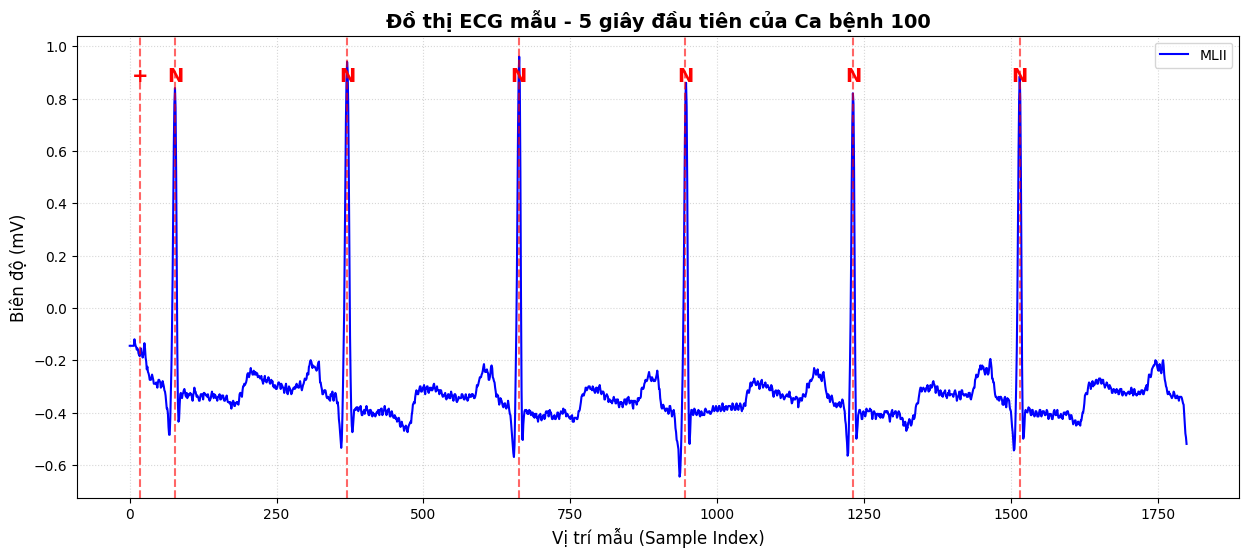

In [ ]:
import wfdb
import matplotlib.pyplot as plt

# Đường dẫn tới file ca bệnh 100 (chỉ cần ghi tên, không cần đuôi file)
record_path = './mitdb/100'

# 1. Đọc tín hiệu ECG (chứa dữ liệu sóng điện tâm đồ)
record = wfdb.rdrecord(record_path)

# 2. Đọc file annotation (chứa vị trí các đỉnh R và nhãn của từng nhịp tim)
annotation = wfdb.rdann(record_path, 'atr')

# Trích xuất thông tin cơ bản
signal = record.p_signal     # Mảng chứa dữ liệu tín hiệu thô
fs = record.fs               # Tần số lấy mẫu (Tập MIT-BIH chuẩn là 360Hz)

print(f"📊 THÔNG TIN CA BỆNH {record.record_name}:")
print(f" - Số lượng kênh tín hiệu: {record.n_sig}")
print(f" - Tên các kênh: {record.sig_name}")
print(f" - Tần số lấy mẫu (Sampling Rate): {fs} Hz")
print(f" - Tổng số mẫu trong file: {len(signal)}")

# 3. Vẽ đồ thị trực quan hóa 5 giây đầu tiên của kênh MLII (kênh đầu tiên - cột 0)
# 5 giây * 360 mẫu/giây = 1800 mẫu
seconds_to_plot = 5
n_samples = seconds_to_plot * fs

plt.figure(figsize=(15, 6))
plt.plot(signal[:n_samples, 0], label=record.sig_name[0], color='blue', linewidth=1.5)

# Lấy các điểm nhịp tim rơi vào khoảng 5 giây đầu này để vẽ nhãn
for idx, sample_pos in enumerate(annotation.sample):
    if sample_pos < n_samples:
        label = annotation.symbol[idx] # Ký hiệu nhãn (Ví dụ: 'N')

        # Vẽ một đường thẳng đứng màu đỏ nét đứt tại vị trí nhịp tim (đỉnh R)
        plt.axvline(x=sample_pos, color='red', linestyle='--', alpha=0.6)
        # Ghi chữ nhãn lên phía trên đỉnh sóng
        plt.text(sample_pos, max(signal[:n_samples, 0]) * 0.9, label,
                 fontsize=14, color='red', weight='bold', ha='center')

plt.title(f"Đồ thị ECG mẫu - 5 giây đầu tiên của Ca bệnh {record.record_name}", fontsize=14, weight='bold')
plt.xlabel("Vị trí mẫu (Sample Index)", fontsize=12)
plt.ylabel("Biên độ (mV)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='both', linestyle=':', alpha=0.5)
plt.show()

In [ ]:
import os
import numpy as np
import wfdb

# Danh sách 48 ca bệnh trong tập dữ liệu MIT-BIH
all_records = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

data_dir = './mitdb'
window_size = 90  # Lấy 90 mẫu trước và 90 mẫu sau đỉnh R -> Tổng cộng 180 mẫu

X = []
y = []

print("⏳ Đang tiến hành tiền xử lý và cắt phân đoạn nhịp tim...")

for record_name in all_records:
    record_path = os.path.join(data_dir, record_name)
    if not os.path.exists(record_path + '.dat'):
        continue  # Bỏ qua nếu thiếu file

    # Đọc kênh tín hiệu thứ nhất (thường là MLII) và file nhãn
    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, 'atr')
    signal = record.p_signal[:, 0]  # Lấy kênh MLII ở cột 0

    # Duyệt qua từng vị trí nhịp tim được đánh dấu
    for idx, sample_pos in enumerate(annotation.sample):
        label_symbol = annotation.symbol[idx]

        # Đảm bảo cửa sổ cắt không bị vượt quá biên của mảng tín hiệu
        if sample_pos - window_size >= 0 and sample_pos + window_size < len(signal):
            # Trích xuất cửa sổ nhịp tim 180 mẫu
            beat = signal[sample_pos - window_size : sample_pos + window_size]

            # Phân loại nhãn: 'N' là Bình thường (0), các nhãn khác là Bất thường (1)
            if label_symbol == 'N':
                beat_label = 0
            elif label_symbol in ['L', 'R', 'A', 'a', 'J', 'S', 'V', 'E', 'F', '/', 'f', 'Q']:
                beat_label = 1
            else:
                continue # Bỏ qua các ký hiệu đặc biệt không phải nhịp tim (như nhiễu, khởi động máy...)

            X.append(beat)
            y.append(beat_label)

# Chuyển đổi sang mảng NumPy
X = np.array(X)
y = np.array(y)

print("\n✅ TIỀN XỬ LÝ HOÀN TẤT!")
print(f" - Tổng số nhịp tim trích xuất được: {X.shape[0]}")
print(f" - Kích thước mỗi nhịp: {X.shape[1]} mẫu")
print(f" - Số lượng nhịp Bình thường (0): {np.sum(y == 0)}")
print(f" - Số lượng nhịp Bất thường (1): {np.sum(y == 1)}")

⏳ Đang tiến hành tiền xử lý và cắt phân đoạn nhịp tim...

✅ TIỀN XỬ LÝ HOÀN TẤT!
 - Tổng số nhịp tim trích xuất được: 109223
 - Kích thước mỗi nhịp: 180 mẫu
 - Số lượng nhịp Bình thường (0): 75033
 - Số lượng nhịp Bất thường (1): 34190


📊 KÍCH THƯỚC DỮ LIỆU SAU KHI CHIA:
 - Tập Huấn luyện (Train): 87378 nhịp
 - Tập Kiểm thử (Test): 21845 nhịp

⏳ Đang huấn luyện mô hình Random Forest (Baseline)... Vui lòng đợi.
✅ Huấn luyện xong!

📋 BÁO CÁO HIỆU SUẤT MÔ HÌNH (CLASSIFICATION REPORT):
                 precision    recall  f1-score   support

Bình thường (0)       0.98      1.00      0.99     15007
 Bất thường (1)       0.99      0.96      0.98      6838

       accuracy                           0.99     21845
      macro avg       0.99      0.98      0.98     21845
   weighted avg       0.99      0.99      0.99     21845



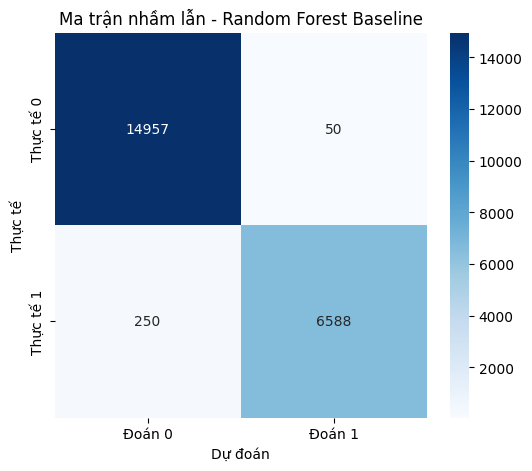

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chia dữ liệu thành 2 tập: Train (80%) và Test (20%)
# Sử dụng stratify=y để đảm bảo tỷ lệ các lớp 0 và 1 đồng đều ở cả 2 tập
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("📊 KÍCH THƯỚC DỮ LIỆU SAU KHI CHIA:")
print(f" - Tập Huấn luyện (Train): {X_train.shape[0]} nhịp")
print(f" - Tập Kiểm thử (Test): {X_test.shape[0]} nhịp\n")

# 2. Khởi tạo mô hình Random Forest
# Thêm class_weight='balanced' để thuật toán tự động xử lý vấn đề mất cân bằng dữ liệu
print("⏳ Đang huấn luyện mô hình Random Forest (Baseline)... Vui lòng đợi.")
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
baseline_model.fit(X_train, y_train)
print("✅ Huấn luyện xong!")

# 3. Dự đoán trên tập dữ liệu Test
y_pred = baseline_model.predict(X_test)

# 4. In báo cáo kết quả chi tiết
print("\n📋 BÁO CÁO HIỆU SUẤT MÔ HÌNH (CLASSIFICATION REPORT):")
print(classification_report(y_test, y_pred, target_names=['Bình thường (0)', 'Bất thường (1)']))

# 5. Vẽ ma trận nhầm lẫn (Confusion Matrix) để trực quan hóa kết quả
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Đoán 0', 'Đoán 1'], yticklabels=['Thực tế 0', 'Thực tế 1'])
plt.title('Ma trận nhầm lẫn - Random Forest Baseline')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 1. Chuyển đổi mảng NumPy sang PyTorch Tensor
# Sử dụng .unsqueeze(-1) để thêm chiều input_size=1 vào cuối (Biến đổi từ [N, 180] thành [N, 180, 1])
X_train_torch = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train_torch = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)

X_test_torch = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test_torch = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

# 2. Cấu hình Batch Size (Kích thước gói dữ liệu đưa vào mỗi lượt huấn luyện)
BATCH_SIZE = 64

# 3. Đóng gói vào TensorDataset và DataLoader
train_dataset = TensorDataset(X_train_torch, y_train_torch)
test_dataset = TensorDataset(X_test_torch, y_test_torch)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("✅ Đã chuyển đổi dữ liệu và cấu hình PyTorch DataLoaders thành công!")
print(f" - Số lượng Batch trong tập Train: {len(train_loader)}")
print(f" - Số lượng Batch trong tập Test: {len(test_loader)}")

✅ Đã chuyển đổi dữ liệu và cấu hình PyTorch DataLoaders thành công!
 - Số lượng Batch trong tập Train: 1366
 - Số lượng Batch trong tập Test: 342


In [ ]:
class ECG_LSTM_Classifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(ECG_LSTM_Classifier, self).__init__()
        # Cấu hình mạng LSTM
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # Tầng phân loại đầu ra (Trả về 1 giá trị logit phục vụ bài toán phân loại nhị phân)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x có kích thước: (batch_size, 180, 1)
        # lstm_out có kích thước: (batch_size, 180, hidden_size)
        lstm_out, (hn, cn) = self.lstm(x)

        # Chúng ta chỉ lấy đầu ra đặc trưng của mốc thời gian cuối cùng (vị trí -1) trong chuỗi 180 mẫu
        last_time_step_out = lstm_out[:, -1, :]

        # Đưa qua tầng tuyến tính để dự đoán nhãn
        out = self.fc(last_time_step_out)
        return out

# Kiểm tra cấu hình thiết bị phần cứng (Ưu tiên chạy bằng GPU T4 miễn phí của Colab)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Khởi tạo mô hình và đẩy lên thiết bị tính toán
model = ECG_LSTM_Classifier().to(device)
print(f"🤖 Mô hình LSTM đã được khởi tạo thành công trên thiết bị: {device}")
print(model)

🤖 Mô hình LSTM đã được khởi tạo thành công trên thiết bị: cuda
ECG_LSTM_Classifier(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
import torch.optim as optim

# 1. Khởi tạo Loss Function và Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Cấu hình số lượt học (Epochs)
# Nhóm chạy thử 10 epoch trước để theo dõi tiến trình giảm Loss
EPOCHS = 10

print("🚀 Bắt đầu quá trình huấn luyện mạng LSTM...")
print("-" * 50)

for epoch in range(EPOCHS):
    model.train()  # Chuyển mô hình sang chế độ huấn luyện (Training Mode)
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        # Đẩy dữ liệu của từng batch lên GPU
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # Làm sạch gradient của lượt tính toán trước
        optimizer.zero_grad()

        # Thực hiện Forward pass (Dự đoán đầu ra)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Thực hiện Backward pass (Tính toán gradient và cập nhật trọng số)
        loss.backward()
        optimizer.step()

        # Thống kê hiệu suất của lượt này
        running_loss += loss.item() * batch_X.size(0)

        # Vì dùng BCEWithLogitsLoss, đầu ra là các giá trị logit thô.
        # Nếu logit > 0 tức là xác suất > 0.5 -> Dự đoán lớp 1 (Bất thường).
        preds = (outputs > 0).float()
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    # Tính Loss và Accuracy trung bình của toàn bộ Epoch
    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] -> Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

print("-" * 50)
print("✅ Huấn luyện mạng LSTM hoàn tất!")

🚀 Bắt đầu quá trình huấn luyện mạng LSTM...
--------------------------------------------------
Epoch [01/10] -> Loss: 0.4864 | Accuracy: 77.80%
Epoch [02/10] -> Loss: 0.4443 | Accuracy: 80.16%
Epoch [03/10] -> Loss: 0.4919 | Accuracy: 77.10%
Epoch [04/10] -> Loss: 0.2221 | Accuracy: 92.19%
Epoch [05/10] -> Loss: 0.1371 | Accuracy: 95.93%
Epoch [06/10] -> Loss: 0.1204 | Accuracy: 96.49%
Epoch [07/10] -> Loss: 0.1130 | Accuracy: 96.77%
Epoch [08/10] -> Loss: 0.1032 | Accuracy: 97.02%
Epoch [09/10] -> Loss: 0.0997 | Accuracy: 97.09%
Epoch [10/10] -> Loss: 0.0867 | Accuracy: 97.48%
--------------------------------------------------
✅ Huấn luyện mạng LSTM hoàn tất!


📋 BÁO CÁO HIỆU SUẤT MÔ HÌNH LSTM (TRÊN TẬP TEST):
                 precision    recall  f1-score   support

Bình thường (0)       0.98      0.99      0.98     15007
 Bất thường (1)       0.97      0.96      0.97      6838

       accuracy                           0.98     21845
      macro avg       0.98      0.97      0.98     21845
   weighted avg       0.98      0.98      0.98     21845



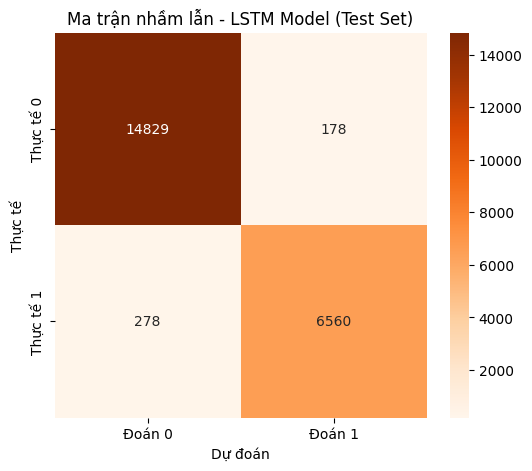

In [ ]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chuyển mô hình sang chế độ đánh giá (Evaluation Mode)
model.eval()

y_true_list = []
y_pred_list = []

# 2. Tắt tính toán gradient để tăng tốc và tiết kiệm bộ nhớ GPU
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Đẩy dữ liệu lên GPU giống như lúc train
        batch_X = batch_X.to(device)

        # Nhận kết quả dự đoán từ mô hình (dạng logit thô)
        outputs = model(batch_X)

        # Nếu logit > 0 tương đương xác suất > 0.5 -> Dự đoán lớp 1 (Bất thường)
        preds = (outputs > 0).float()

        # Đưa dữ liệu từ GPU về CPU và chuyển sang mảng NumPy để tính toán metric
        y_true_list.extend(batch_y.numpy())
        y_pred_list.extend(preds.cpu().numpy())

# Chuyển thành mảng phẳng (flatten) để đưa vào hàm tính toán của sklearn
y_true_all = np.array(y_true_list).flatten()
y_pred_all = np.array(y_pred_list).flatten()

# 3. In báo cáo kết quả chi tiết cho LSTM
print("📋 BÁO CÁO HIỆU SUẤT MÔ HÌNH LSTM (TRÊN TẬP TEST):")
print(classification_report(y_true_all, y_pred_all, target_names=['Bình thường (0)', 'Bất thường (1)']))

# 4. Vẽ ma trận nhầm lẫn (Confusion Matrix) để trực quan hóa kết quả đoán đúng/sai
cm_lstm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Đoán 0', 'Đoán 1'], yticklabels=['Thực tế 0', 'Thực tế 1'])
plt.title('Ma trận nhầm lẫn - LSTM Model (Test Set)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Định nghĩa cấu trúc mạng RNN truyền thống
class ECG_RNN_Classifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(ECG_RNN_Classifier, self).__init__()
        # Thay thế nn.LSTM bằng nn.RNN truyền thống
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch_size, 180, 1)
        rnn_out, hn = self.rnn(x)
        # Lấy đầu ra tại mốc thời gian cuối cùng của chuỗi tín hiệu
        last_time_step_out = rnn_out[:, -1, :]
        out = self.fc(last_time_step_out)
        return out

# 2. Khởi tạo mô hình RNN và đẩy lên GPU
model_rnn = ECG_RNN_Classifier().to(device)
criterion_rnn = nn.BCEWithLogitsLoss()
optimizer_rnn = optim.Adam(model_rnn.parameters(), lr=0.001)

print("🤖 Mô hình RNN đã được khởi tạo thành công trên cấu hình GPU!")
print("-" * 50)

# 3. Vòng lặp huấn luyện mạng RNN trong 10 Epoch
EPOCHS = 10
for epoch in range(EPOCHS):
    model_rnn.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer_rnn.zero_grad()
        outputs = model_rnn(batch_X)
        loss = criterion_rnn(outputs, batch_y)

        loss.backward()
        optimizer_rnn.step()

        running_loss += loss.item() * batch_X.size(0)
        preds = (outputs > 0).float()
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] -> Loss: {running_loss/total:.4f} | Accuracy: {(correct/total)*100:.2f}%")

print("-" * 50)
print("✅ Huấn luyện mạng RNN hoàn tất!")

🤖 Mô hình RNN đã được khởi tạo thành công trên cấu hình GPU!
--------------------------------------------------
Epoch [01/10] -> Loss: 0.5913 | Accuracy: 71.04%
Epoch [02/10] -> Loss: 0.5856 | Accuracy: 71.39%
Epoch [03/10] -> Loss: 0.5843 | Accuracy: 71.40%
Epoch [04/10] -> Loss: 0.5777 | Accuracy: 71.61%
Epoch [05/10] -> Loss: 0.5920 | Accuracy: 70.75%
Epoch [06/10] -> Loss: 0.5792 | Accuracy: 71.92%
Epoch [07/10] -> Loss: 0.5875 | Accuracy: 70.80%
Epoch [08/10] -> Loss: 0.5925 | Accuracy: 69.50%
Epoch [09/10] -> Loss: 0.5496 | Accuracy: 71.47%
Epoch [10/10] -> Loss: 0.5472 | Accuracy: 71.76%
--------------------------------------------------
✅ Huấn luyện mạng RNN hoàn tất!


📋 BÁO CÁO HIỆU SUẤT MÔ HÌNH RNN (TRÊN TẬP TEST):
                 precision    recall  f1-score   support

Bình thường (0)       0.75      0.88      0.81     15007
 Bất thường (1)       0.58      0.37      0.45      6838

       accuracy                           0.72     21845
      macro avg       0.67      0.62      0.63     21845
   weighted avg       0.70      0.72      0.70     21845



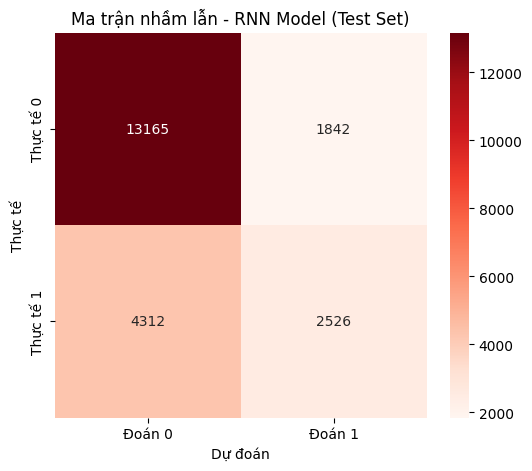

In [ ]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chuyển mô hình RNN sang chế độ đánh giá (Evaluation Mode)
model_rnn.eval()

y_true_list_rnn = []
y_pred_list_rnn = []

# 2. Tắt tính toán gradient để tiết kiệm bộ nhớ GPU
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Đẩy dữ liệu lên GPU giống như lúc huấn luyện
        batch_X = batch_X.to(device)

        # Nhận kết quả dự đoán từ mô hình RNN
        outputs = model_rnn(batch_X)
        preds = (outputs > 0).float()

        # Chuyển dữ liệu về CPU để xử lý mảng
        y_true_list_rnn.extend(batch_y.numpy())
        y_pred_list_rnn.extend(preds.cpu().numpy())

# Phẳng hóa mảng dữ liệu
y_true_all_rnn = np.array(y_true_list_rnn).flatten()
y_pred_all_rnn = np.array(y_pred_list_rnn).flatten()

# 3. In báo cáo kết quả chi tiết cho mạng RNN
print("📋 BÁO CÁO HIỆU SUẤT MÔ HÌNH RNN (TRÊN TẬP TEST):")
print(classification_report(y_true_all_rnn, y_pred_all_rnn, target_names=['Bình thường (0)', 'Bất thường (1)']))

# 4. Vẽ ma trận nhầm lẫn (Confusion Matrix) màu đỏ để phân biệt với LSTM
cm_rnn = confusion_matrix(y_true_all_rnn, y_pred_all_rnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Đoán 0', 'Đoán 1'], yticklabels=['Thực tế 0', 'Thực tế 1'])
plt.title('Ma trận nhầm lẫn - RNN Model (Test Set)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Lọc riêng các nhịp tim Bình thường (nhãn 0) từ tập Train ban đầu để huấn luyện Autoencoder
X_train_normal = X_train[y_train == 0]

# Chuyển sang định dạng PyTorch Tensor (Autoencoder dạng Tuyến tính nhận mảng 2D: [Batch_size, 180])
X_train_ae = torch.tensor(X_train_normal, dtype=torch.float32)
# Tập Test vẫn giữ nguyên cả nhịp bình thường và bất thường để đánh giá khả năng bắt lỗi
X_test_ae = torch.tensor(X_test, dtype=torch.float32)
y_test_ae = torch.tensor(y_test, dtype=torch.float32)

# 2. Đóng gói vào DataLoader
BATCH_SIZE_AE = 64
train_loader_ae = DataLoader(TensorDataset(X_train_ae), batch_size=BATCH_SIZE_AE, shuffle=True)

print("✅ Đã chuẩn bị dữ liệu cho Autoencoder:")
print(f" - Số lượng nhịp Bình thường dùng để Train: {X_train_ae.shape[0]}")
print(f" - Số lượng nhịp dùng để Test (Hỗn hợp): {X_test_ae.shape[0]}")

✅ Đã chuẩn bị dữ liệu cho Autoencoder:
 - Số lượng nhịp Bình thường dùng để Train: 60026
 - Số lượng nhịp dùng để Test (Hỗn hợp): 21845


In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Định nghĩa cấu trúc mạng Autoencoder (180 -> 64 -> 32 -> 64 -> 180)
class ECG_Autoencoder(nn.Module):
    def __init__(self):
        super(ECG_Autoencoder, self).__init__()
        # Encoder: Nén chuỗi tín hiệu 180 mẫu xuống không gian ẩn (latent space) 32 chiều
        self.encoder = nn.Sequential(
            nn.Linear(180, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        # Decoder: Khôi phục từ 32 chiều trở lại dải tín hiệu 180 mẫu ban đầu
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 180)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

# 2. Khởi tạo mô hình và đẩy lên GPU
model_ae = ECG_Autoencoder().to(device)
criterion_ae = nn.MSELoss() # Dùng sai số bình phương trung bình để đo độ khớp của tín hiệu
optimizer_ae = optim.Adam(model_ae.parameters(), lr=0.001)

print("🚀 Đang huấn luyện Autoencoder trên các nhịp tim bình thường...")
print("-" * 50)

EPOCHS_AE = 10
for epoch in range(EPOCHS_AE):
    model_ae.train()
    running_loss = 0.0

    for batch_data in train_loader_ae:
        inputs = batch_data[0].to(device)

        optimizer_ae.zero_grad()
        outputs = model_ae(inputs)

        # Hàm mất mát so sánh độ giống nhau giữa đầu ra khôi phục và đầu vào gốc
        loss = criterion_ae(outputs, inputs)
        loss.backward()
        optimizer_ae.step()

        running_loss += loss.item() * inputs.size(0)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS_AE}] -> Reconstruction Loss: {running_loss / len(train_loader_ae.dataset):.5f}")

print("-" * 50)
print("✅ Huấn luyện Autoencoder hoàn tất!")

🚀 Đang huấn luyện Autoencoder trên các nhịp tim bình thường...
--------------------------------------------------
Epoch [01/10] -> Reconstruction Loss: 0.01691
Epoch [02/10] -> Reconstruction Loss: 0.00266
Epoch [03/10] -> Reconstruction Loss: 0.00178
Epoch [04/10] -> Reconstruction Loss: 0.00137
Epoch [05/10] -> Reconstruction Loss: 0.00123
Epoch [06/10] -> Reconstruction Loss: 0.00110
Epoch [07/10] -> Reconstruction Loss: 0.00100
Epoch [08/10] -> Reconstruction Loss: 0.00093
Epoch [09/10] -> Reconstruction Loss: 0.00113
Epoch [10/10] -> Reconstruction Loss: 0.00089
--------------------------------------------------
✅ Huấn luyện Autoencoder hoàn tất!


🎯 Ngưỡng phát hiện bất thường được chọn: 0.00640

📋 BÁO CÁO HIỆU SUẤT MÔ HÌNH AUTOENCODER:
                 precision    recall  f1-score   support

Bình thường (0)       0.80      0.99      0.88     15007
 Bất thường (1)       0.95      0.46      0.62      6838

       accuracy                           0.82     21845
      macro avg       0.88      0.72      0.75     21845
   weighted avg       0.85      0.82      0.80     21845



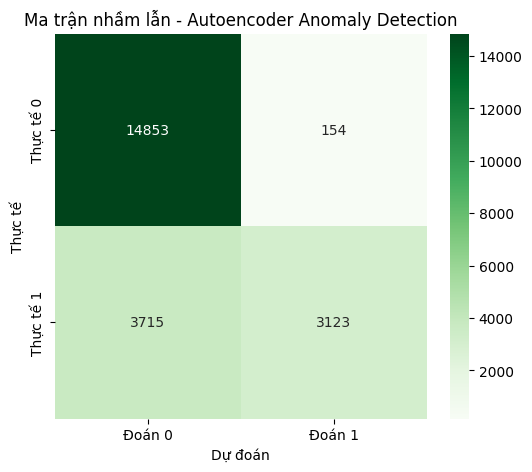

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

model_ae.eval()
errors = []

# Tính sai số tái cấu trúc cho từng nhịp trong tập Test
with torch.no_grad():
    inputs = X_test_ae.to(device)
    outputs = model_ae(inputs)
    # Tính Mean Squared Error theo từng hàng (từng nhịp tim)
    mse_errors = torch.mean((outputs - inputs) ** 2, dim=1)
    errors = mse_errors.cpu().numpy()

# Chọn ngưỡng bằng phân vị thứ 85 của sai số (Có thể tinh chỉnh con số này để tối ưu Recall)
threshold = np.percentile(errors, 85)
y_pred_ae = [1 if e > threshold else 0 for e in errors]

print(f"🎯 Ngưỡng phát hiện bất thường được chọn: {threshold:.5f}\n")
print("📋 BÁO CÁO HIỆU SUẤT MÔ HÌNH AUTOENCODER:")
print(classification_report(y_test, y_pred_ae, target_names=['Bình thường (0)', 'Bất thường (1)']))

# Vẽ ma trận nhầm lẫn màu xanh lá cho Autoencoder
cm_ae = confusion_matrix(y_test, y_pred_ae)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Đoán 0', 'Đoán 1'], yticklabels=['Thực tế 0', 'Thực tế 1'])
plt.title('Ma trận nhầm lẫn - Autoencoder Anomaly Detection')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

In [ ]:
!pip install wfdb -q

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import torch
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

print("📁 HỆ THỐNG KIỂM TRA FILE NGOÀI VỚI LSTM (BẢN CHUẨN KAGGLE - ĐÃ TỐI ƯU ĐỈNH)")
print("-" * 75)
print("Hãy bấm 'Choose Files' và chọn file ECG (.csv) của bạn:")

# ==========================================================
# BƯỚC 1: UPLOAD FILE
# ==========================================================
uploaded = files.upload()

if len(uploaded) == 0:
    print("⚠️ Bạn chưa chọn file nào. Hãy chạy lại ô code này nhé!")
else:
    file_name = list(uploaded.keys())[0]

    # ==========================================================
    # BƯỚC 2: ĐỌC FILE VÀ BÓC TÁCH KÊNH MLII
    # ==========================================================
    try:
        df = pd.read_csv(file_name)
        df.columns = [c.strip() for c in df.columns] # Làm sạch tên cột

        if 'MLII' in df.columns:
            external_signal = df['MLII'].values
            print(f"\n✅ Đã bóc tách thành công kênh tín hiệu 'MLII'!")
        else:
            external_signal = df.iloc[:, 1].values
            print(f"\n✅ Không thấy cột MLII, mặc định lấy cột tín hiệu thứ 2.")

        print(f"✅ Đọc file '{file_name}' thành công! Tổng số mẫu: {len(external_signal)}")

        # BỘ LỌC CHUẨN HÓA KAGGLE (ADC -> mV)
        if np.mean(external_signal) > 500:
            external_signal = (external_signal - 1024) / 200.0
            print("⚙️ Đã tự động chuyển đổi thang đo tín hiệu thô (ADC) về chuẩn Y khoa (mV).")

        # ==========================================================
        # BƯỚC 3: DÒ ĐỈNH THÔNG MINH (BẮT CẢ ĐỈNH ĐẢO NGƯỢC)
        # ==========================================================
        # Trừ đi trung vị để đưa đường nền về sát 0, sau đó lấy abs() để lật tất cả đỉnh âm thành đỉnh dương
        signal_centered = external_signal - np.median(external_signal)
        search_signal = np.abs(signal_centered)

        # Tìm đỉnh trên tín hiệu trị tuyệt đối
        r_peaks, _ = find_peaks(search_signal, distance=200, prominence=0.4)
        print(f"⚡ Tự động tìm thấy {len(r_peaks)} nhịp tim trong file này.")

        # ==========================================================
        # BƯỚC 4: QUÉT VÀ PHÂN LOẠI THÔNG MINH
        # ==========================================================
        model.eval()
        window_size = 90

        normal_beats_to_show = []
        abnormal_beats_to_show = []

        print("\n🤖 AI ĐANG QUÉT TOÀN BỘ FILE ĐỂ LỌC KẾT QUẢ...")

        for idx, pos in enumerate(r_peaks):
            if pos - window_size >= 0 and pos + window_size < len(external_signal):
                beat = external_signal[pos - window_size : pos + window_size]

                # Nạp vào AI dự đoán
                beat_tensor = torch.tensor(beat, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
                with torch.no_grad():
                    output = model(beat_tensor)
                    probability = torch.sigmoid(output).item()

                pred_label = "Bất thường (1)" if probability > 0.5 else "Bình thường (0)"
                beat_data = {
                    'idx': idx + 1,
                    'pos': pos,
                    'beat': beat,
                    'prob': probability,
                    'label': pred_label
                }

                # Gom nhóm kết quả
                if probability > 0.5 and len(abnormal_beats_to_show) < 3:
                    abnormal_beats_to_show.append(beat_data)
                elif probability <= 0.5 and len(normal_beats_to_show) < 2:
                    normal_beats_to_show.append(beat_data)

            # Dừng sớm nếu đã tìm đủ mẫu để hiển thị trực quan
            if len(abnormal_beats_to_show) >= 3 and len(normal_beats_to_show) >= 2:
                break

        # ==========================================================
        # BƯỚC 5: HIỂN THỊ TRỰC QUAN HÓA KẾT QUẢ ĐA DẠNG
        # ==========================================================
        beats_to_display = normal_beats_to_show + abnormal_beats_to_show

        print("=" * 75)
        print(f"📊 KẾT QUẢ PHÂN TÍCH ĐIỂM HÌNH (Hiển thị tối đa 2 nhịp Thường & 3 nhịp Bất thường tìm thấy):")
        print("=" * 75)

        if len(beats_to_display) == 0:
            print("Không có đủ dữ liệu nhịp hợp lệ để hiển thị.")

        for b in beats_to_display:
            print(f"📍 Nhịp tim số {b['idx']} tại vị trí mẫu {b['pos']}:")
            print(f"  -> AI dự đoán: {b['label']} (Xác suất bất thường: {b['prob']*100:.2f}%)")

            # Vẽ đồ thị từng nhịp
            plt.figure(figsize=(7, 3.2))
            color = '#d63031' if b['prob'] > 0.5 else '#0984e3'
            plt.plot(b['beat'], color=color, linewidth=2, label=f"Dự đoán: {b['label']}")
            plt.axvline(x=90, color='gray', linestyle=':', label='Đỉnh R (Tâm cửa sổ)')
            plt.title(f"Nhịp số {b['idx']} tại Sample {b['pos']} | Xác suất Abnormal: {b['prob']*100:.2f}%", fontsize=10, weight='bold')
            plt.xlabel("Mẫu thời gian (Samples)")
            plt.ylabel("Biên độ (mV)")
            plt.legend(loc='upper right')
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
            print("-" * 75)

    except Exception as e:
        print(f"❌ Lỗi xử lý: {e}")

📁 HỆ THỐNG KIỂM TRA FILE NGOÀI VỚI LSTM (BẢN CHUẨN KAGGLE - ĐÃ TỐI ƯU ĐỈNH)
---------------------------------------------------------------------------
Hãy bấm 'Choose Files' và chọn file ECG (.csv) của bạn:


⚠️ Bạn chưa chọn file nào. Hãy chạy lại ô code này nhé!


📁 HỆ THỐNG KIỂM TRA ECG ĐA ĐỊNH DẠNG (HỖ TRỢ CẢ CSV VÀ FILE GỐC .HEA/.DAT)
--------------------------------------------------------------------------------
💡 HƯỚNG DẪN: Bấm 'Choose Files' và chọn:
   👉 Cách 1: Chọn 1 file '.csv' (Ví dụ: 201_ekg.csv)
   👉 Cách 2: Chọn CẢ HAI file '.hea' và '.dat' cùng lúc (Ví dụ: 201.hea và 201.dat)
--------------------------------------------------------------------------------


Saving 200.dat to 200.dat
Saving 200.hea to 200.hea

📦 Đã nhận diện: Chế độ đọc file gốc WFDB ('200')
✅ Đã tìm thấy và bóc tách kênh 'MLII' (Kênh số 1)
⚙️ [Thông tin]: Tín hiệu đã được tự động chuẩn hóa về mV từ file cấu hình.
📊 Tổng số mẫu tín hiệu nạp vào hệ thống: 650000
⚡ Tự động tìm thấy 2109 nhịp tim trong file này.

🤖 AI ĐANG QUÉT TOÀN BỘ FILE ĐỂ LỌC KẾT QUẢ...
📊 KẾT QUẢ PHÂN TÍCH ĐIỂM HÌNH (Chế độ dữ liệu đầu vào: WFDB):
📍 Nhịp tim số 2 tại vị trí mẫu 488:
  -> AI dự đoán: Bình thường (0) (Xác suất bất thường: 0.83%)


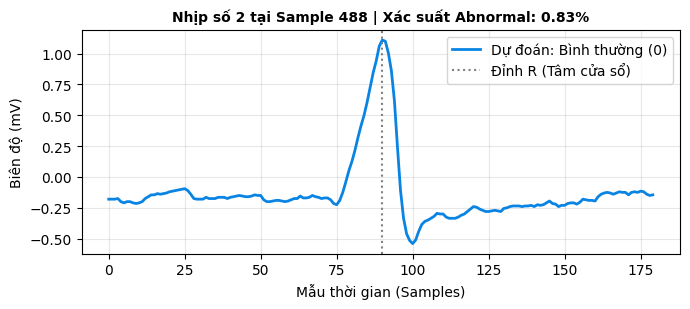

--------------------------------------------------------------------------------
📍 Nhịp tim số 8 tại vị trí mẫu 2786:
  -> AI dự đoán: Bình thường (0) (Xác suất bất thường: 13.20%)


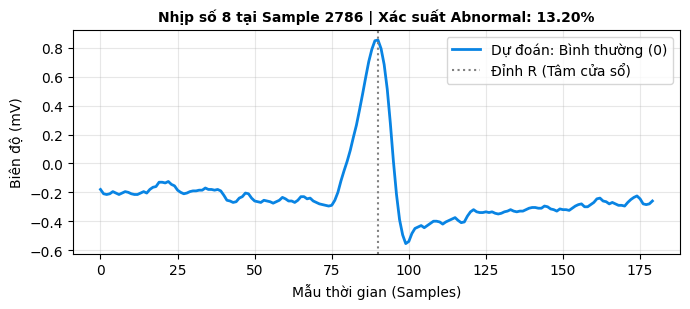

--------------------------------------------------------------------------------
📍 Nhịp tim số 1 tại vị trí mẫu 224:
  -> AI dự đoán: Bất thường (1) (Xác suất bất thường: 98.92%)


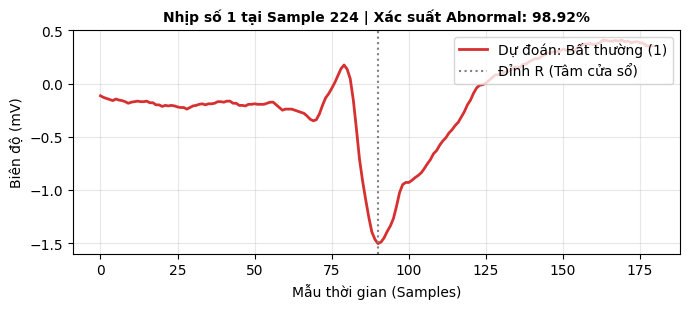

--------------------------------------------------------------------------------
📍 Nhịp tim số 3 tại vị trí mẫu 689:
  -> AI dự đoán: Bất thường (1) (Xác suất bất thường: 99.24%)


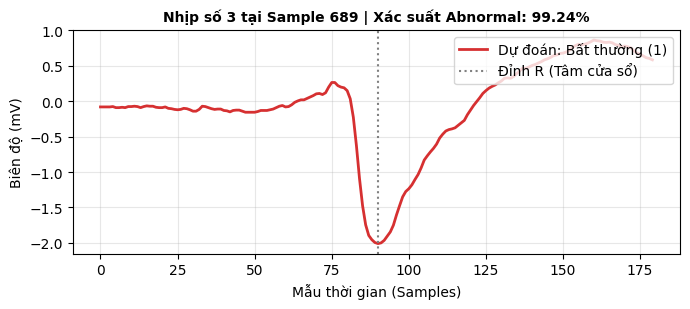

--------------------------------------------------------------------------------
📍 Nhịp tim số 4 tại vị trí mẫu 1147:
  -> AI dự đoán: Bất thường (1) (Xác suất bất thường: 99.33%)


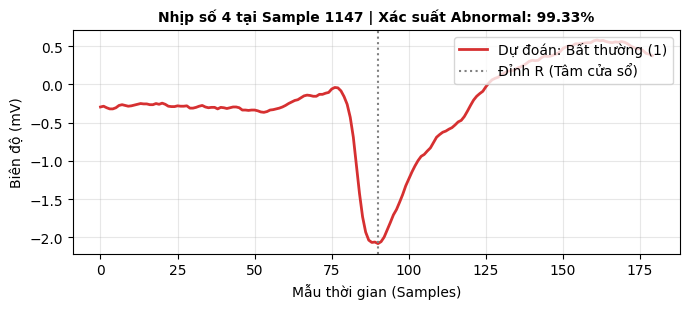

--------------------------------------------------------------------------------


In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import torch
import os
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Thử import wfdb, nếu chưa có thì tự cài tự động
try:
    import wfdb
except ImportError:
    print("📦 Đang cài đặt thư viện wfdb cho file gốc...")
    import os
    os.system('pip install wfdb -q')
    import wfdb

print("📁 HỆ THỐNG KIỂM TRA ECG ĐA ĐỊNH DẠNG (HỖ TRỢ CẢ CSV VÀ FILE GỐC .HEA/.DAT)")
print("-" * 80)
print("💡 HƯỚNG DẪN: Bấm 'Choose Files' và chọn:")
print("   👉 Cách 1: Chọn 1 file '.csv' (Ví dụ: 201_ekg.csv)")
print("   👉 Cách 2: Chọn CẢ HAI file '.hea' và '.dat' cùng lúc (Ví dụ: 201.hea và 201.dat)")
print("-" * 80)

# ==========================================================
# BƯỚC 1: UPLOAD FILE
# ==========================================================
uploaded = files.upload()

if len(uploaded) == 0:
    print("⚠️ Bạn chưa chọn file nào. Hãy chạy lại ô code này nhé!")
else:
    uploaded_file_names = list(uploaded.keys())

    # Phân loại file vừa upload
    csv_files = [f for f in uploaded_file_names if f.endswith('.csv')]
    hea_files = [f for f in uploaded_file_names if f.endswith('.hea')]

    external_signal = None
    mode = ""

    # ==========================================================
    # BƯỚC 2: TỰ ĐỘNG NHẬN DIỆN VÀ XỬ LÝ ĐỊNH DẠNG
    # ==========================================================
    try:
        # TRƯỜNG HỢP 1: NGƯỜI DÙNG NHẬP FILE CSV
        if len(csv_files) > 0:
            mode = "CSV"
            file_name = csv_files[0]
            print(f"\n📝 Đạt nhận diện: Chế độ đọc file CSV ('{file_name}')")

            df = pd.read_csv(file_name)
            df.columns = [c.strip() for c in df.columns] # Làm sạch tên cột

            if 'MLII' in df.columns:
                external_signal = df['MLII'].values
                print("✅ Đã bóc tách thành công kênh tín hiệu 'MLII'!")
            else:
                external_signal = df.iloc[:, 1].values
                print(f"⚠️ Không thấy cột MLII, mặc định lấy cột tín hiệu thứ 2: '{df.columns[1]}'")

            # Bộ lọc chuẩn hóa số thô ADC về mV cho file CSV Kaggle
            if np.mean(external_signal) > 500:
                external_signal = (external_signal - 1024) / 200.0
                print("⚙️ Đã tự động chuyển đổi thang đo tín hiệu thô (ADC) về chuẩn Y khoa (mV).")

        # TRƯỜNG HỢP 2: NGƯỜI DÙNG NHẬP FILE GỐC .HEA + .DAT
        elif len(hea_files) > 0:
            mode = "WFDB"
            record_name = hea_files[0].replace('.hea', '')
            print(f"\n📦 Đã nhận diện: Chế độ đọc file gốc WFDB ('{record_name}')")

            if f"{record_name}.dat" not in uploaded_file_names:
                raise Exception(f"Thiếu file dữ liệu nhị phân '{record_name}.dat' đi kèm!")

            record = wfdb.rdrecord(record_name)
            if 'MLII' in record.sig_name:
                channel_idx = record.sig_name.index('MLII')
                external_signal = record.p_signal[:, channel_idx]
                print(f"✅ Đã tìm thấy và bóc tách kênh 'MLII' (Kênh số {channel_idx + 1})")
            else:
                external_signal = record.p_signal[:, 0]
                print(f"⚠️ Không thấy kênh MLII, mặc định lấy kênh đầu tiên: '{record.sig_name[0]}'")
            print("⚙️ [Thông tin]: Tín hiệu đã được tự động chuẩn hóa về mV từ file cấu hình.")

        else:
            print("❌ Lỗi: Định dạng file bạn upload không hợp lệ (Phải là .csv hoặc cặp .hea/.dat)!")

        # ==========================================================
        # BƯỚC 3: DÒ ĐỈNH & CHẠY AI (DÙNG CHUNG CHO CẢ 2 ĐỊNH DẠNG)
        # ==========================================================
        if external_signal is not None:
            print(f"📊 Tổng số mẫu tín hiệu nạp vào hệ thống: {len(external_signal)}")

            # Khử đường nền trung vị và lấy Trị tuyệt đối để bắt cả đỉnh âm/dương
            signal_centered = external_signal - np.median(external_signal)
            search_signal = np.abs(signal_centered)

            r_peaks, _ = find_peaks(search_signal, distance=200, prominence=0.4)
            print(f"⚡ Tự động tìm thấy {len(r_peaks)} nhịp tim trong file này.")

            model.eval()
            window_size = 90

            normal_beats_to_show = []
            abnormal_beats_to_show = []

            print("\n🤖 AI ĐANG QUÉT TOÀN BỘ FILE ĐỂ LỌC KẾT QUẢ...")

            for idx, pos in enumerate(r_peaks):
                if pos - window_size >= 0 and pos + window_size < len(external_signal):
                    beat = external_signal[pos - window_size : pos + window_size]

                    # Nạp vào mạng LSTM
                    beat_tensor = torch.tensor(beat, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
                    with torch.no_grad():
                        output = model(beat_tensor)
                        probability = torch.sigmoid(output).item()

                    pred_label = "Bất thường (1)" if probability > 0.5 else "Bình thường (0)"
                    beat_data = {
                        'idx': idx + 1,
                        'pos': pos,
                        'beat': beat,
                        'prob': probability,
                        'label': pred_label
                    }

                    # Bộ lọc thông minh gom nhóm hiển thị
                    if probability > 0.5 and len(abnormal_beats_to_show) < 3:
                        abnormal_beats_to_show.append(beat_data)
                    elif probability <= 0.5 and len(normal_beats_to_show) < 2:
                        normal_beats_to_show.append(beat_data)

                if len(abnormal_beats_to_show) >= 3 and len(normal_beats_to_show) >= 2:
                    break

            # ==========================================================
            # BƯỚC 4: HIỂN THỊ ĐỒ THỊ KẾT QUẢ
            # ==========================================================
            beats_to_display = normal_beats_to_show + abnormal_beats_to_show

            print("=" * 80)
            print(f"📊 KẾT QUẢ PHÂN TÍCH ĐIỂM HÌNH (Chế độ dữ liệu đầu vào: {mode}):")
            print("=" * 80)

            if len(beats_to_display) == 0:
                print("Không có đủ dữ liệu nhịp hợp lệ để hiển thị.")

            for b in beats_to_display:
                print(f"📍 Nhịp tim số {b['idx']} tại vị trí mẫu {b['pos']}:")
                print(f"  -> AI dự đoán: {b['label']} (Xác suất bất thường: {b['prob']*100:.2f}%)")

                plt.figure(figsize=(7, 3.2))
                color = '#d63031' if b['prob'] > 0.5 else '#0984e3'
                plt.plot(b['beat'], color=color, linewidth=2, label=f"Dự đoán: {b['label']}")
                plt.axvline(x=90, color='gray', linestyle=':', label='Đỉnh R (Tâm cửa sổ)')
                plt.title(f"Nhịp số {b['idx']} tại Sample {b['pos']} | Xác suất Abnormal: {b['prob']*100:.2f}%", fontsize=10, weight='bold')
                plt.xlabel("Mẫu thời gian (Samples)")
                plt.ylabel("Biên độ (mV)")
                plt.legend(loc='upper right')
                plt.grid(alpha=0.3)
                plt.tight_layout()
                plt.show()
                print("-" * 80)

    except Exception as e:
        print(f"❌ Lỗi xử lý: {e}")

📁 HỆ THỐNG KIỂM TRA ECG ĐA ĐỊNH DẠNG (BẢN SỬA LỖI TRÙNG TÊN COLAB)
--------------------------------------------------------------------------------
💡 HƯỚNG DẪN: Bấm 'Choose Files' và chọn file .csv HOẶC cặp .hea/.dat cùng lúc.
--------------------------------------------------------------------------------


Saving 201.dat to 201.dat
Saving 201.hea to 201.hea

📦 Đã nhận diện: Chế độ đọc file gốc WFDB ('201')
✅ Đã tìm thấy và bóc tách kênh 'MLII' (Kênh số 1)
⚙️ [Thông tin]: Tín hiệu đã được tự động chuẩn hóa về mV từ file cấu hình.
📊 Tổng số mẫu tín hiệu nạp vào hệ thống: 650000
⚡ Tự động tìm thấy 1718 nhịp tim trong file này.

🤖 AI ĐANG QUÉT TOÀN BỘ FILE ĐỂ LỌC KẾT QUẢ...
📊 KẾT QUẢ PHÂN TÍCH ĐIỂM HÌNH (Chế độ dữ liệu đầu vào: WFDB):
📍 Nhịp tim số 1 tại vị trí mẫu 160:
  -> AI dự đoán: Bình thường (0) (Xác suất bất thường: 12.10%)


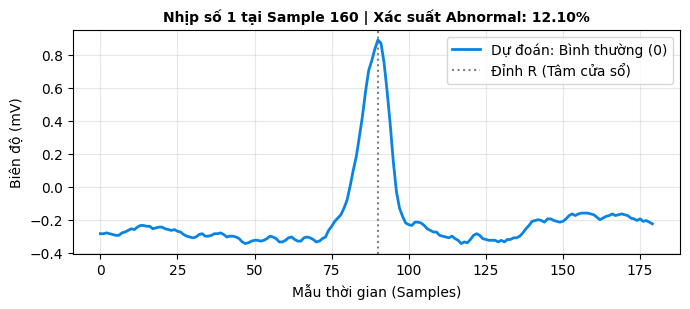

--------------------------------------------------------------------------------
📍 Nhịp tim số 2 tại vị trí mẫu 416:
  -> AI dự đoán: Bình thường (0) (Xác suất bất thường: 0.79%)


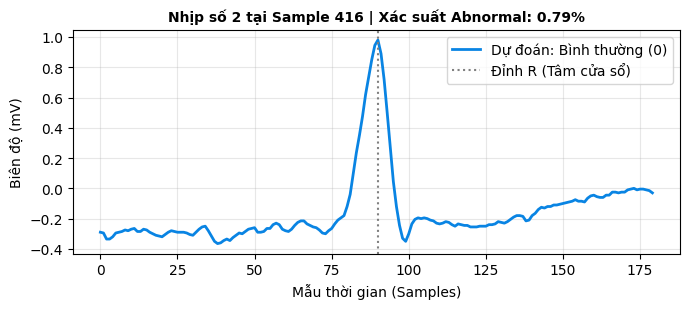

--------------------------------------------------------------------------------
📍 Nhịp tim số 481 tại vị trí mẫu 143138:
  -> AI dự đoán: Bất thường (1) (Xác suất bất thường: 99.05%)


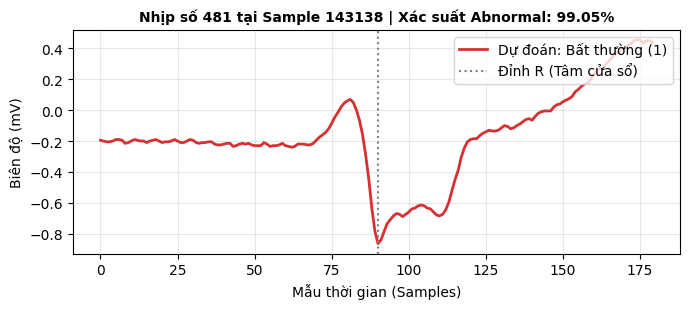

--------------------------------------------------------------------------------
📍 Nhịp tim số 486 tại vị trí mẫu 145220:
  -> AI dự đoán: Bất thường (1) (Xác suất bất thường: 98.89%)


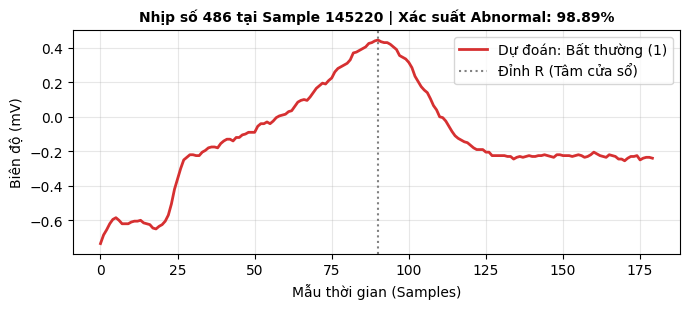

--------------------------------------------------------------------------------
📍 Nhịp tim số 506 tại vị trí mẫu 154031:
  -> AI dự đoán: Bất thường (1) (Xác suất bất thường: 99.37%)


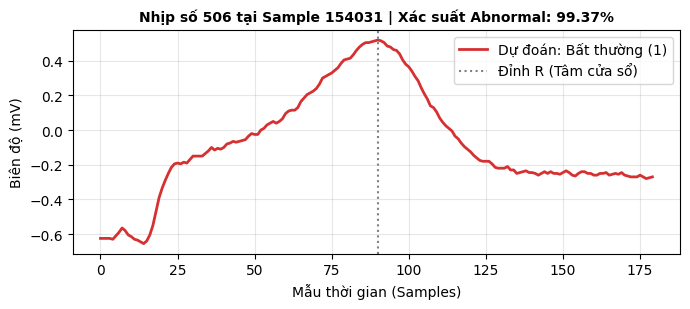

--------------------------------------------------------------------------------


In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import torch
import os
import re
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Thử import wfdb, nếu chưa có thì tự cài tự động
try:
    import wfdb
except ImportError:
    print("📦 Đang cài đặt thư viện wfdb cho file gốc...")
    os.system('pip install wfdb -q')
    import wfdb

print("📁 HỆ THỐNG KIỂM TRA ECG ĐA ĐỊNH DẠNG (BẢN SỬA LỖI TRÙNG TÊN COLAB)")
print("-" * 80)
print("💡 HƯỚNG DẪN: Bấm 'Choose Files' và chọn file .csv HOẶC cặp .hea/.dat cùng lúc.")
print("-" * 80)

# ==========================================================
# BƯỚC 1: UPLOAD FILE
# ==========================================================
uploaded = files.upload()

if len(uploaded) == 0:
    print("⚠️ Bạn chưa chọn file nào. Hãy chạy lại ô code này nhé!")
else:
    # 💥 BỘ SỬA LỖI TỰ ĐỘNG: Xử lý hiện tượng Colab tự đổi tên thành "file (1).dat"
    for uploaded_name in list(uploaded.keys()):
        if " (" in uploaded_name:
            # Dùng Regex để loại bỏ phần " (1)", " (2)"... ra khỏi tên file
            original_name = re.sub(r'\s\(\d+\)', '', uploaded_name)

            # Nếu file cũ trùng tên đang tồn tại, xóa nó đi để nhường chỗ cho file mới
            if os.path.exists(original_name):
                os.remove(original_name)

            # Đổi tên file vừa upload về tên chuẩn gốc
            os.rename(uploaded_name, original_name)
            print(f"🔄 Phát hiện trùng lặp! Đã đồng bộ lại tên: '{uploaded_name}' -> '{original_name}'")

    # Lấy lại danh sách file chính thức sau khi đã dọn dẹp và đổi tên chuẩn
    current_files = os.listdir('.')

    # Xác định các file vừa được xử lý dựa trên những gì người dùng vừa nạp lên
    actual_uploaded_clean = [re.sub(r'\s\(\d+\)', '', f) for f in uploaded.keys()]

    csv_files = [f for f in actual_uploaded_clean if f.endswith('.csv')]
    hea_files = [f for f in actual_uploaded_clean if f.endswith('.hea')]

    external_signal = None
    mode = ""

    # ==========================================================
    # BƯỚC 2: TỰ ĐỘNG NHẬN DIỆN VÀ XỬ LÝ ĐỊNH DẠNG
    # ==========================================================
    try:
        # TRƯỜNG HỢP 1: NGƯỜI DÙNG NHẬP FILE CSV
        if len(csv_files) > 0:
            mode = "CSV"
            file_name = csv_files[0]
            print(f"\n📝 Đã nhận diện: Chế độ đọc file CSV ('{file_name}')")

            df = pd.read_csv(file_name)
            df.columns = [c.strip() for c in df.columns]

            if 'MLII' in df.columns:
                external_signal = df['MLII'].values
                print("✅ Đã bóc tách thành công kênh tín hiệu 'MLII'!")
            else:
                external_signal = df.iloc[:, 1].values
                print(f"⚠️ Không thấy cột MLII, mặc định lấy cột tín hiệu thứ 2: '{df.columns[1]}'")

            if np.mean(external_signal) > 500:
                external_signal = (external_signal - 1024) / 200.0
                print("⚙️ Đã tự động chuyển đổi thang đo tín hiệu thô (ADC) về chuẩn Y khoa (mV).")

        # TRƯỜNG HỢP 2: NGƯỜI DÙNG NHẬP FILE GỐC .HEA + .DAT
        elif len(hea_files) > 0:
            mode = "WFDB"
            record_name = hea_files[0].replace('.hea', '')
            print(f"\n📦 Đã nhận diện: Chế độ đọc file gốc WFDB ('{record_name}')")

            # Kiểm tra xem file .dat chuẩn đã có trên đĩa chưa
            if f"{record_name}.dat" not in os.listdir('.'):
                raise Exception(f"Thiếu file dữ liệu nhị phân '{record_name}.dat' đi kèm!")

            record = wfdb.rdrecord(record_name)
            if 'MLII' in record.sig_name:
                channel_idx = record.sig_name.index('MLII')
                external_signal = record.p_signal[:, channel_idx]
                print(f"✅ Đã tìm thấy và bóc tách kênh 'MLII' (Kênh số {channel_idx + 1})")
            else:
                external_signal = record.p_signal[:, 0]
                print(f"⚠️ Không thấy kênh MLII, mặc định lấy kênh đầu tiên: '{record.sig_name[0]}'")
            print("⚙️ [Thông tin]: Tín hiệu đã được tự động chuẩn hóa về mV từ file cấu hình.")

        else:
            print("❌ Lỗi: Định dạng file bạn upload không hợp lệ (Phải là .csv hoặc cặp .hea/.dat)!")

        # ==========================================================
        # BƯỚC 3: DÒ ĐỈNH & CHẠY AI
        # ==========================================================
        if external_signal is not None:
            print(f"📊 Tổng số mẫu tín hiệu nạp vào hệ thống: {len(external_signal)}")

            signal_centered = external_signal - np.median(external_signal)
            search_signal = np.abs(signal_centered)

            r_peaks, _ = find_peaks(search_signal, distance=200, prominence=0.4)
            print(f"⚡ Tự động tìm thấy {len(r_peaks)} nhịp tim trong file này.")

            model.eval()
            window_size = 90

            normal_beats_to_show = []
            abnormal_beats_to_show = []

            print("\n🤖 AI ĐANG QUÉT TOÀN BỘ FILE ĐỂ LỌC KẾT QUẢ...")

            for idx, pos in enumerate(r_peaks):
                if pos - window_size >= 0 and pos + window_size < len(external_signal):
                    beat = external_signal[pos - window_size : pos + window_size]

                    beat_tensor = torch.tensor(beat, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
                    with torch.no_grad():
                        output = model(beat_tensor)
                        probability = torch.sigmoid(output).item()

                    pred_label = "Bất thường (1)" if probability > 0.5 else "Bình thường (0)"
                    beat_data = {
                        'idx': idx + 1,
                        'pos': pos,
                        'beat': beat,
                        'prob': probability,
                        'label': pred_label
                    }

                    if probability > 0.5 and len(abnormal_beats_to_show) < 3:
                        abnormal_beats_to_show.append(beat_data)
                    elif probability <= 0.5 and len(normal_beats_to_show) < 2:
                        normal_beats_to_show.append(beat_data)

                if len(abnormal_beats_to_show) >= 3 and len(normal_beats_to_show) >= 2:
                    break

            # ==========================================================
            # BƯỚC 4: HIỂN THỊ ĐỒ THỊ KẾT QUẢ
            # ==========================================================
            beats_to_display = normal_beats_to_show + abnormal_beats_to_show

            print("=" * 80)
            print(f"📊 KẾT QUẢ PHÂN TÍCH ĐIỂM HÌNH (Chế độ dữ liệu đầu vào: {mode}):")
            print("=" * 80)

            if len(beats_to_display) == 0:
                print("Không có đủ dữ liệu nhịp hợp lệ để hiển thị.")

            for b in beats_to_display:
                print(f"📍 Nhịp tim số {b['idx']} tại vị trí mẫu {b['pos']}:")
                print(f"  -> AI dự đoán: {b['label']} (Xác suất bất thường: {b['prob']*100:.2f}%)")

                plt.figure(figsize=(7, 3.2))
                color = '#d63031' if b['prob'] > 0.5 else '#0984e3'
                plt.plot(b['beat'], color=color, linewidth=2, label=f"Dự đoán: {b['label']}")
                plt.axvline(x=90, color='gray', linestyle=':', label='Đỉnh R (Tâm cửa sổ)')
                plt.title(f"Nhịp số {b['idx']} tại Sample {b['pos']} | Xác suất Abnormal: {b['prob']*100:.2f}%", fontsize=10, weight='bold')
                plt.xlabel("Mẫu thời gian (Samples)")
                plt.ylabel("Biên độ (mV)")
                plt.legend(loc='upper right')
                plt.grid(alpha=0.3)
                plt.tight_layout()
                plt.show()
                print("-" * 80)

    except Exception as e:
        print(f"❌ Lỗi xử lý: {e}")

🔍 ĐANG SĂN LÙNG VÀ PHÂN TÍCH THEO THỜI GIAN SIÊU CHÍNH XÁC
📋 Định vị:               Gõ trên Web 7m 11s 60ms -> Tự động khớp vào đỉnh R chuẩn (Lệch -27.8 ms)
⏱️ Khớp chính xác trên Web: 7 phút 11 giây 31 mili giây
🤖 AI đánh giá nhịp này:  🚨 BẤT THƯỜNG (1)
📊 Xác suất bệnh lý:       99.7427%
---------------------------------------------------------------------------


/tmp/ipykernel_2028/1393836133.py:82: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


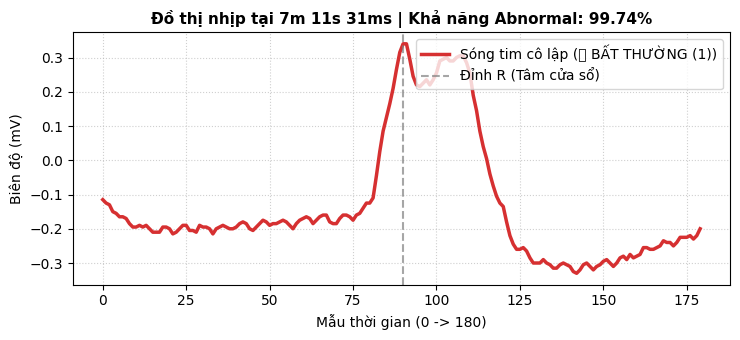

In [ ]:
#@title 🎯 BỘ KIỂM TRA NHỊP ĐƠN LẺ (NHẬP PHÚT, GIÂY & MILI GIÂY CHÍNH XÁC)

Cach_Test = "Theo Thời Gian (Phút:Giây:Ms)" #@param ["Theo STT Nhịp (Beat Index)", "Theo Thời Gian (Phút:Giây:Ms)"]
So_Thu_Tu_Nhip = 1 #@param {type:"integer"}

# Ô nhập thời gian chi tiết đến từng mili giây
Nhap_So_Phut = 7 #@param {type:"integer"}
Nhap_So_Giay = 11 #@param {type:"integer"}
Nhap_Mili_Giay = 60 #@param {type:"integer"}

if 'external_signal' not in locals() or 'r_peaks' not in locals():
    print("❌ Lỗi: Hệ thống không tìm thấy dữ liệu! Hãy chạy ô code Upload ở trên trước nhé.")
else:
    window_size = 90
    pos = None
    ten_nhip = ""

    if Cach_Test == "Theo STT Nhịp (Beat Index)":
        idx = So_Thu_Tu_Nhip - 1
        if 0 <= idx < len(r_peaks):
            pos = r_peaks[idx]
            ten_nhip = f"Nhịp số {So_Thu_Tu_Nhip}"
        else:
            print(f"❌ Lỗi: File này chỉ có {len(r_peaks)} nhịp. Bạn hãy nhập STT từ 1 đến {len(r_peaks)}.")
    else:
        # 🧮 QUY ĐỔI CHÍNH XÁC TOÀN BỘ SANG GIÂY (1 ms = 0.001 giây)
        tong_so_giay = (Nhap_So_Phut * 60) + Nhap_So_Giay + (Nhap_Mili_Giay / 1000.0)
        sample_uoc_luong = int(tong_so_giay * 360)

        # 💥 BỘ CÂN ĐỈNH TỰ ĐỘNG: Tìm đỉnh R thật gần nhất với thời gian siêu chính xác bạn nhập
        closest_peak_idx = np.argmin(np.abs(r_peaks - sample_uoc_luong))
        pos = r_peaks[closest_peak_idx]
        khoang_lech_mau = pos - sample_uoc_luong
        khoang_lech_ms = (khoang_lech_mau / 360.0) * 1000.0

        if abs(khoang_lech_mau) > 180:
            pos = sample_uoc_luong
            ten_nhip = f"Mốc {Nhap_So_Phut}:{Nhap_So_Giay}.{Nhap_Mili_Giay} (Không tìm thấy đỉnh R nào ở quá gần)"
        else:
            ten_nhip = f"Gõ trên Web {Nhap_So_Phut}m {Nhap_So_Giay}s {Nhap_Mili_Giay}ms -> Tự động khớp vào đỉnh R chuẩn (Lệch {khoang_lech_ms:.1f} ms)"

    if pos is not None:
        if pos - window_size >= 0 and pos + window_size < len(external_signal):
            beat = external_signal[pos - window_size : pos + window_size]

            # Tính lại thời gian chuẩn của đỉnh R sau khi hút
            giay_web = pos / 360.0
            phut_chuan = int(giay_web // 60)
            giay_chuan = int(giay_web % 60)
            ms_chuan = int(round((giay_web % 1) * 1000))

            # AI chạy dự đoán
            model.eval()
            beat_tensor = torch.tensor(beat, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
            with torch.no_grad():
                output = model(beat_tensor)
                probability = torch.sigmoid(output).item()

            label = "🚨 BẤT THƯỜNG (1)" if probability > 0.5 else "✅ BÌNH THƯỜNG (0)"

            print("=" * 75)
            print(f"🔍 ĐANG SĂN LÙNG VÀ PHÂN TÍCH THEO THỜI GIAN SIÊU CHÍNH XÁC")
            print("=" * 75)
            print(f"📋 Định vị:               {ten_nhip}")
            print(f"⏱️ Khớp chính xác trên Web: {phut_chuan} phút {giay_chuan} giây {ms_chuan} mili giây")
            print(f"🤖 AI đánh giá nhịp này:  {label}")
            print(f"📊 Xác suất bệnh lý:       {probability * 100:.4f}%")
            print("-" * 75)

            # Vẽ đồ thị phóng to
            plt.figure(figsize=(7.5, 3.5))
            mau_sac = '#d63031' if probability > 0.5 else '#0984e3'

            plt.plot(beat, color=mau_sac, linewidth=2.5, label=f"Sóng tim cô lập ({label})")
            plt.axvline(x=90, color='gray', linestyle='--', alpha=0.7, label='Đỉnh R (Tâm cửa sổ)')

            plt.title(f"Đồ thị nhịp tại {phut_chuan}m {giay_chuan}s {ms_chuan}ms | Khả năng Abnormal: {probability*100:.2f}%", fontsize=11, weight='bold')
            plt.xlabel("Mẫu thời gian (0 -> 180)")
            plt.ylabel("Biên độ (mV)")
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.legend(loc='upper right')
            plt.tight_layout()
            plt.show()
        else:
            print("❌ Lỗi: Vị trí thời gian này nằm ngoài phạm vi file dữ liệu!")